# Obesity Level Prediction System

## Dataset Overview
This dataset contains information about individuals from Mexico, Peru, and Colombia. It includes demographic details, eating habits, physical condition, and family history. The goal is to predict the obesity level of a person.

## Real-world Problem Framing
Obesity is a major public health issue linked to diabetes, heart disease, and reduced quality of life. Early prediction based on lifestyle factors can help in prevention programs, personalised health advice, and public health planning.

## Why Machine Learning is Suitable
Traditional BMI calculation (weight/height²) is simple but does not consider eating habits, physical activity, or family history. ML can learn complex patterns from multiple features to classify obesity levels more accurately.

## Project Objectives and Success Metrics
- Build a multi-class classifier to predict one of 7 obesity levels.
- Achieve high macro F1-score (balanced performance across all classes).
- Develop a user-friendly Streamlit app for real-time prediction.
- Document the full development process with strong engineering practices.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adeniranstephen/obesity-prediction-dataset")
print("Path to dataset files:", path)

# List files in the downloaded path to see the exact filename
import os
print(os.listdir(path))

Using Colab cache for faster access to the 'obesity-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/obesity-prediction-dataset
['.nfs000000009405db5e00000065', 'ObesityDataSet_raw_and_data_sinthetic.csv']


In [4]:
data_path = path + '/ObesityDataSet_raw_and_data_sinthetic.csv'

df = pd.read_csv(data_path)

# Initial inspection
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include='all'))

print("\nTarget variable unique values:")
print(df['NObeyesdad'].unique())

Dataset Shape: (2111, 17)

First 5 rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.315964,1.701620,86.586035,NaN,NaN,2.418986,2.685651,NaN,NaN,2.008053,NaN,1.010313,0.657861,NaN,NaN,NaN
std,NaN,6.357078,0.093368,26.191163,NaN,NaN,0.533996,0.778079,NaN,NaN,0.612950,NaN,0.850613,0.608926,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,20.000000,1.630000,65.470000,NaN,NaN,2.000000,2.660000,NaN,NaN,1.585000,NaN,0.125000,0.000000,NaN,NaN,NaN
50%,NaN,23.000000,1.700000,83.000000,NaN,NaN,2.390000,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625000,NaN,NaN,NaN
75%,NaN,26.000000,1.770000,107.430000,NaN,NaN,3.000000,3.000000,NaN,NaN,2.480000,NaN,1.670000,1.000000,NaN,NaN,NaN



Target variable unique values:
['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


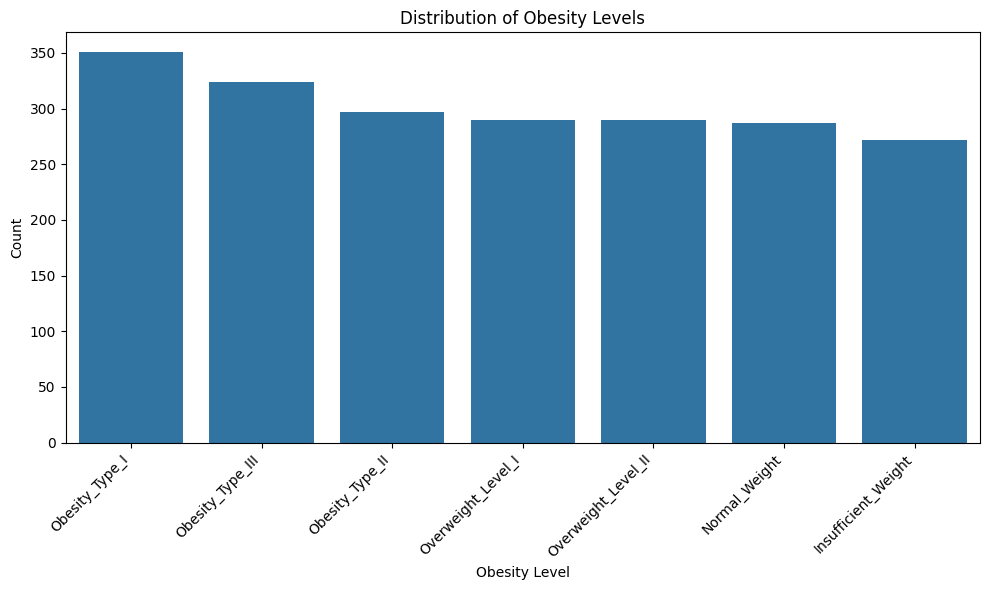

Target class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target variable distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.title('Distribution of Obesity Levels')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('target_distribution.png')   # ← SAVE THIS for report
plt.show()

print("Target class distribution:")
print(df['NObeyesdad'].value_counts())

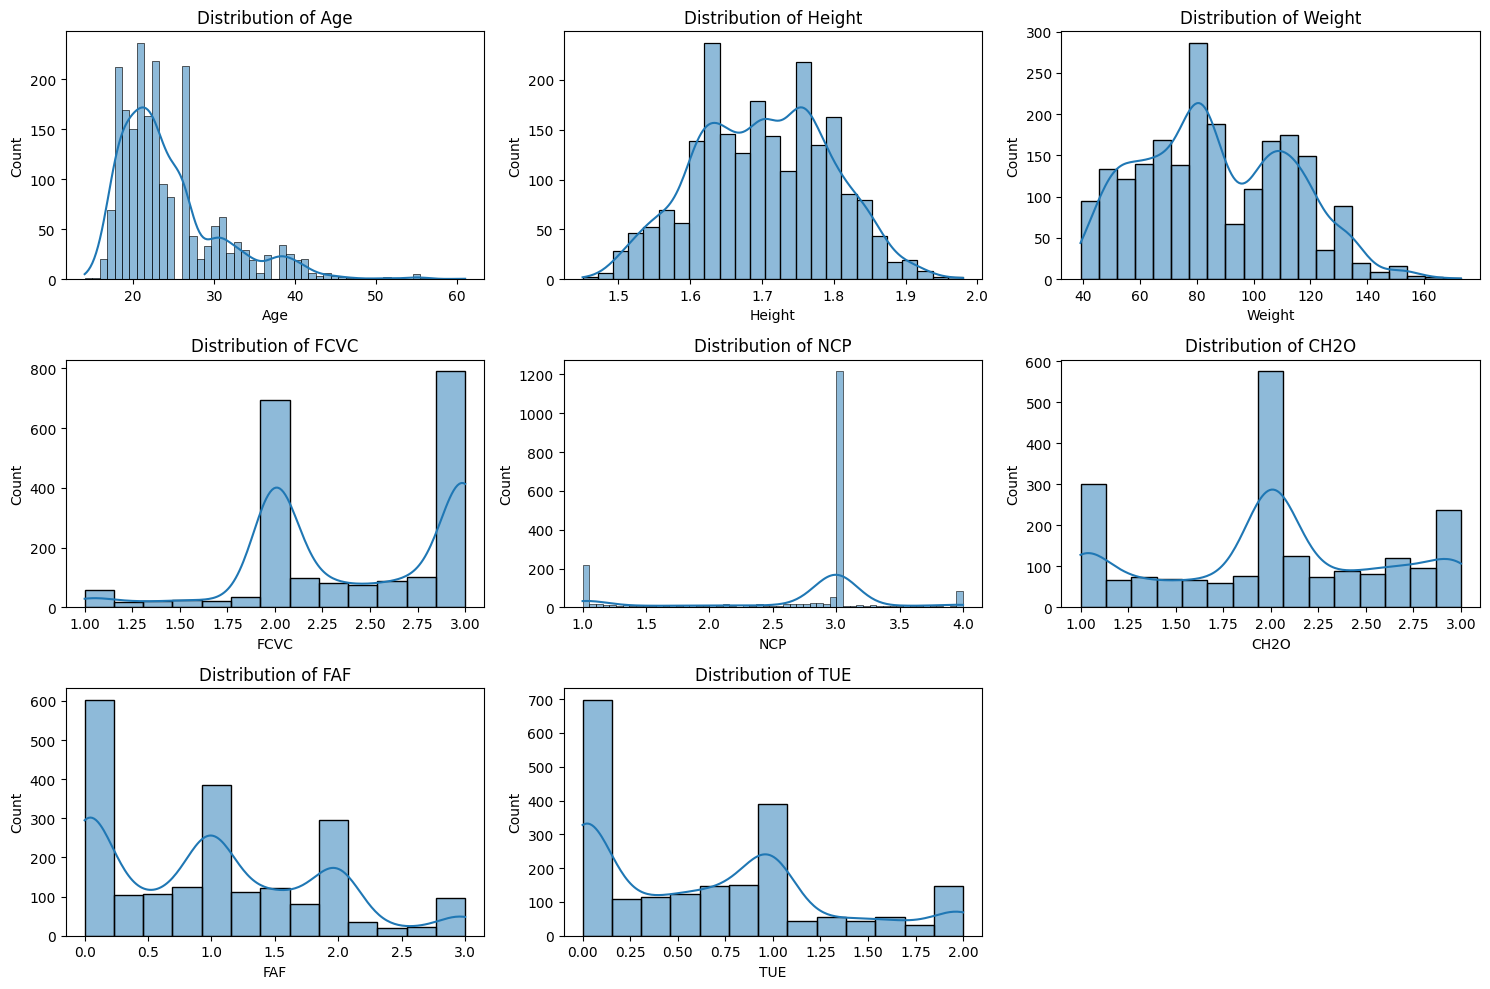

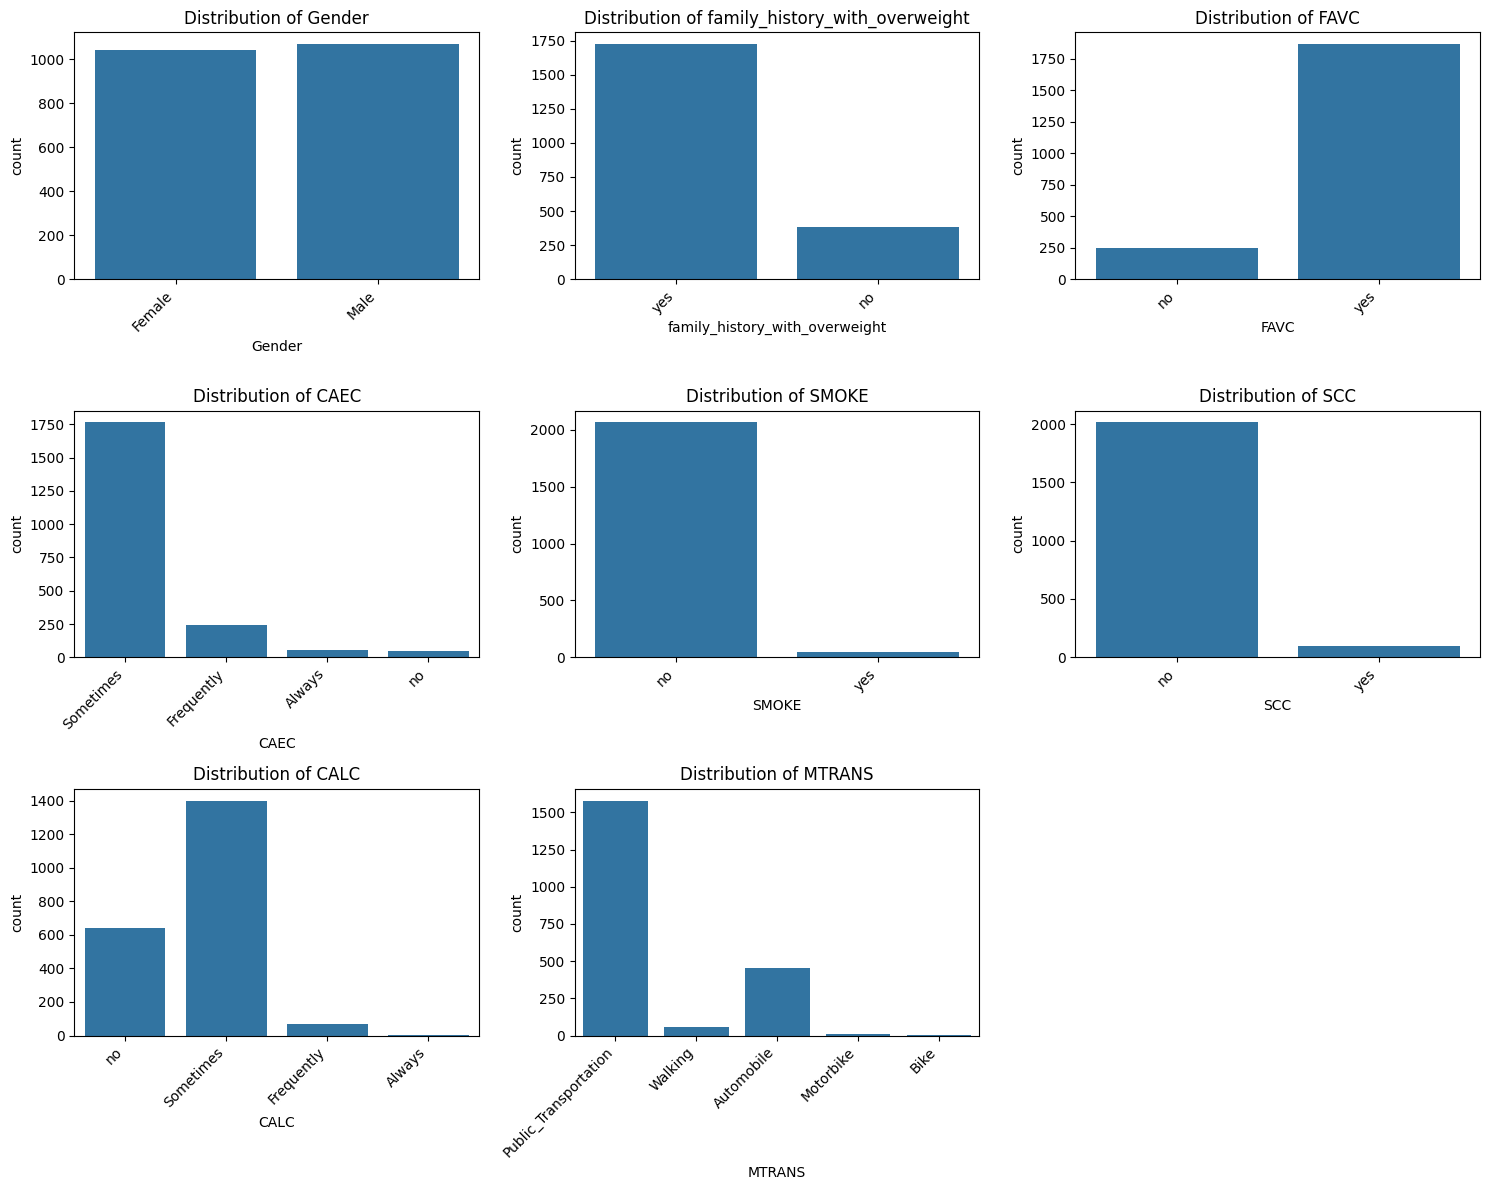

In [6]:
# Numerical features histograms
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('numerical_distributions.png')   # ← SAVE THIS
plt.show()

# Categorical features countplots
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
            'SMOKE', 'SCC', 'CALC', 'MTRANS']
plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('categorical_distributions.png')   # ← SAVE THIS
plt.show()

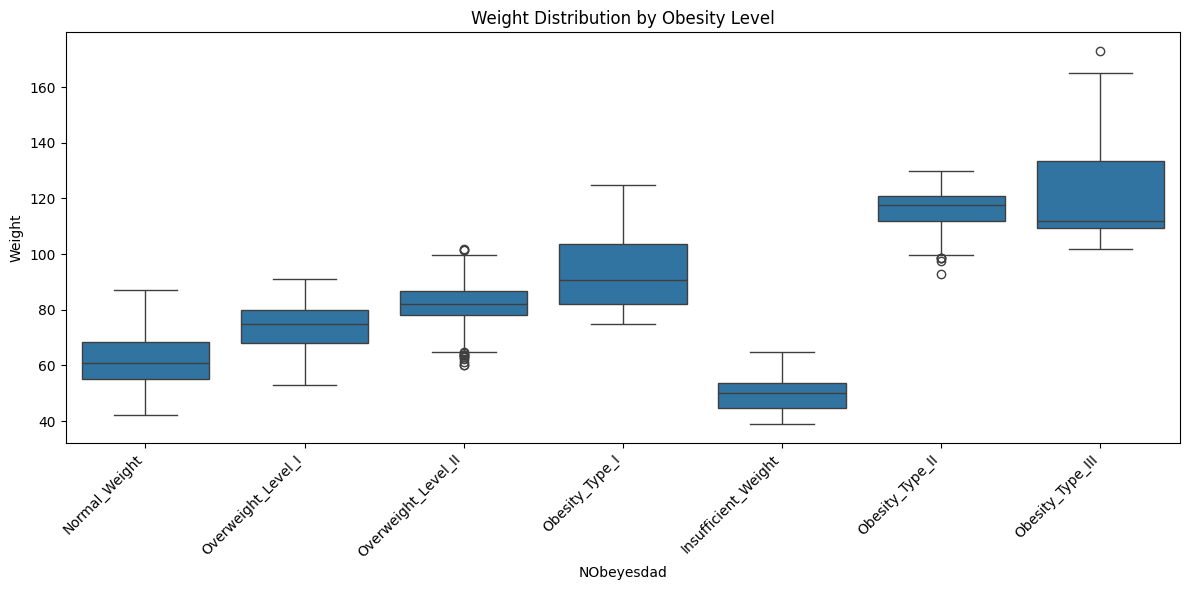

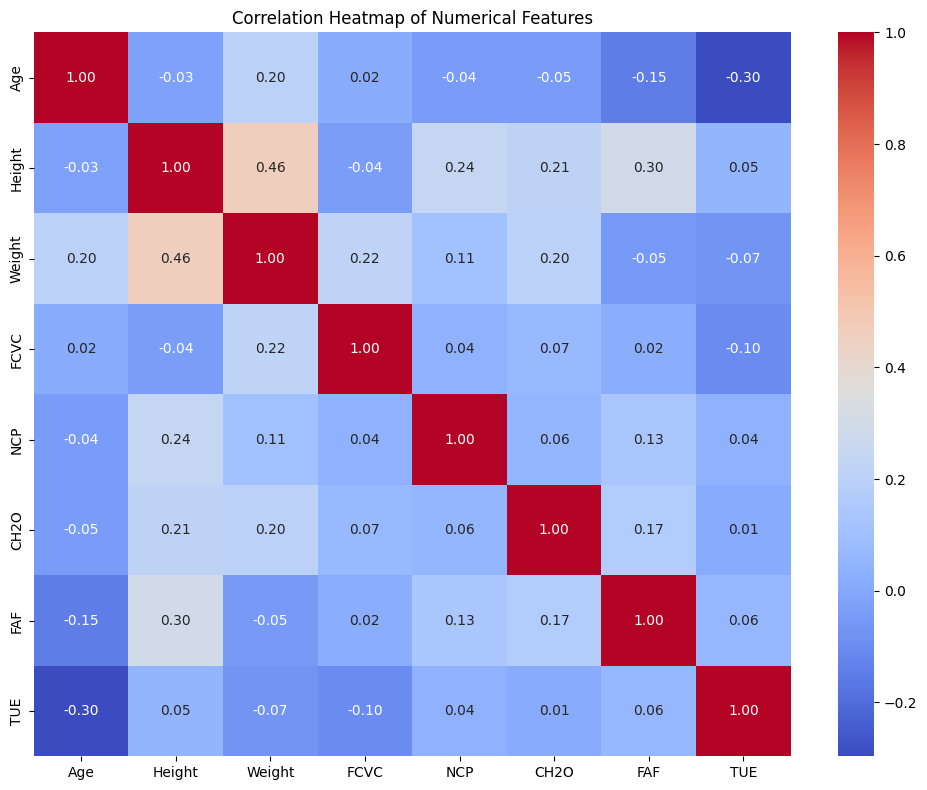

In [7]:
# Boxplots: Weight vs Obesity Level
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='NObeyesdad', y='Weight')
plt.title('Weight Distribution by Obesity Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('weight_by_obesity.png')   # ← SAVE THIS
plt.show()

# Correlation heatmap (numerical features only)
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')   # ← SAVE THIS
plt.show()

## EDA Insights and Initial Observations

- The dataset is balanced across the 7 obesity levels with no extreme class imbalance.
- Weight shows the strongest relationship with the target variable.
- Height and Weight are moderately correlated as expected.
- Most people have family history of overweight.
- High frequency of consuming high caloric food (FAVC = yes) is common.
- Physical activity (FAF) and screen time (TUE) vary significantly.
- Very few people smoke or monitor calories (SCC = yes).

In [8]:
# 1. Check missing values and duplicates
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()

# 2. Create new feature: BMI
df['bmi'] = df['Weight'] / (df['Height'] ** 2)

# 3. Separate features and target
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# 4. Identify numerical and categorical columns
num_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'bmi']
cat_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
                'SMOKE', 'SCC', 'CALC', 'MTRANS']

print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Missing values: 0
Duplicate rows: 24
Numerical features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'bmi']
Categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Label encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Target classes mapping:")
for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', 'passthrough', cat_features)  # we'll one-hot encode later in full pipeline
    ])

# For now, manually one-hot encode categorical features for exploration
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
print("\nNew features created:", list(X_encoded.columns[-10:]))  # show last 10

Target classes mapping:
0 -> Insufficient_Weight
1 -> Normal_Weight
2 -> Obesity_Type_I
3 -> Obesity_Type_II
4 -> Obesity_Type_III
5 -> Overweight_Level_I
6 -> Overweight_Level_II
Shape after encoding: (2087, 24)

New features created: ['CAEC_no', 'SMOKE_yes', 'SCC_yes', 'CALC_Frequently', 'CALC_Sometimes', 'CALC_no', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


In [10]:
from sklearn.model_selection import train_test_split

# Final split: 70% train, 15% validation, 15% test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)
print("\nClass distribution preserved (train):")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

Train set shape: (1460, 24)
Validation set shape: (313, 24)
Test set shape: (314, 24)

Class distribution preserved (train):
2    0.168
4    0.155
3    0.142
6    0.139
1    0.135
5    0.132
0    0.128
Name: proportion, dtype: float64



=== Logistic Regression ===
Validation Accuracy: 0.9105
Training Time: 0.24 seconds
                     precision    recall  f1-score   support

Insufficient_Weight      0.976     1.000     0.988        40
      Normal_Weight      0.867     0.907     0.886        43
     Obesity_Type_I      0.891     0.925     0.907        53
    Obesity_Type_II      0.935     0.977     0.956        44
   Obesity_Type_III      1.000     0.979     0.989        48
 Overweight_Level_I      0.837     0.857     0.847        42
Overweight_Level_II      0.861     0.721     0.785        43

           accuracy                          0.911       313
          macro avg      0.909     0.909     0.908       313
       weighted avg      0.910     0.911     0.909       313



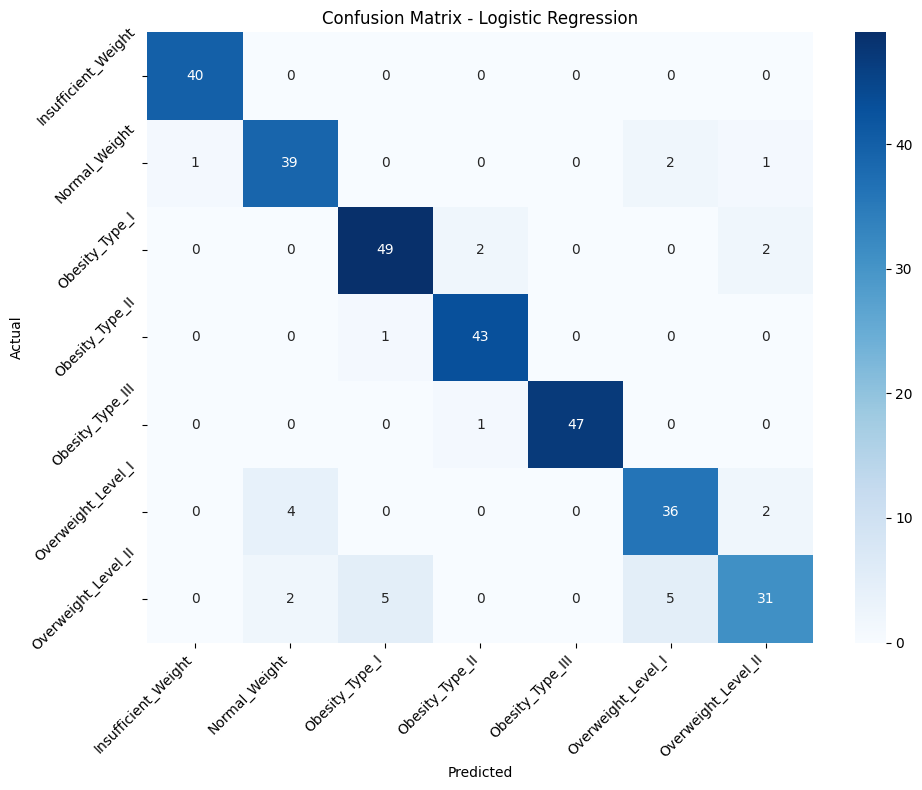


=== Decision Tree ===
Validation Accuracy: 0.9521
Training Time: 0.07 seconds
                     precision    recall  f1-score   support

Insufficient_Weight      1.000     0.975     0.987        40
      Normal_Weight      0.875     0.977     0.923        43
     Obesity_Type_I      0.963     0.981     0.972        53
    Obesity_Type_II      0.955     0.955     0.955        44
   Obesity_Type_III      1.000     0.979     0.989        48
 Overweight_Level_I      0.944     0.810     0.872        42
Overweight_Level_II      0.933     0.977     0.955        43

           accuracy                          0.952       313
          macro avg      0.953     0.950     0.950       313
       weighted avg      0.954     0.952     0.952       313



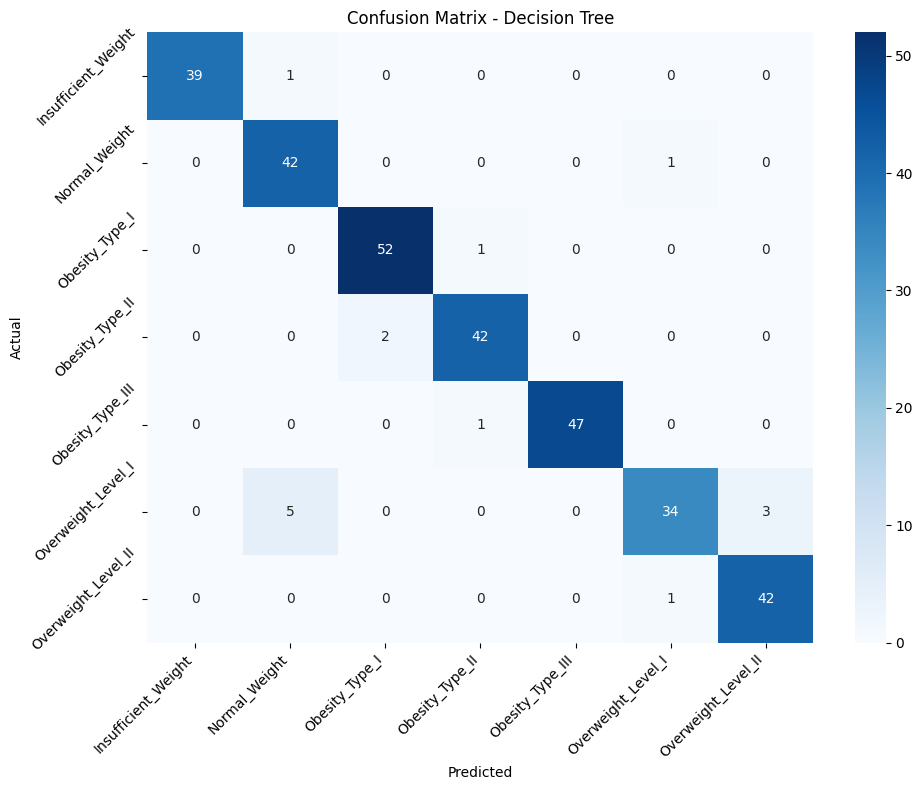


=== Random Forest ===
Validation Accuracy: 0.9808
Training Time: 3.05 seconds
                     precision    recall  f1-score   support

Insufficient_Weight      1.000     0.975     0.987        40
      Normal_Weight      0.896     1.000     0.945        43
     Obesity_Type_I      1.000     1.000     1.000        53
    Obesity_Type_II      0.978     1.000     0.989        44
   Obesity_Type_III      1.000     0.979     0.989        48
 Overweight_Level_I      1.000     0.929     0.963        42
Overweight_Level_II      1.000     0.977     0.988        43

           accuracy                          0.981       313
          macro avg      0.982     0.980     0.980       313
       weighted avg      0.983     0.981     0.981       313



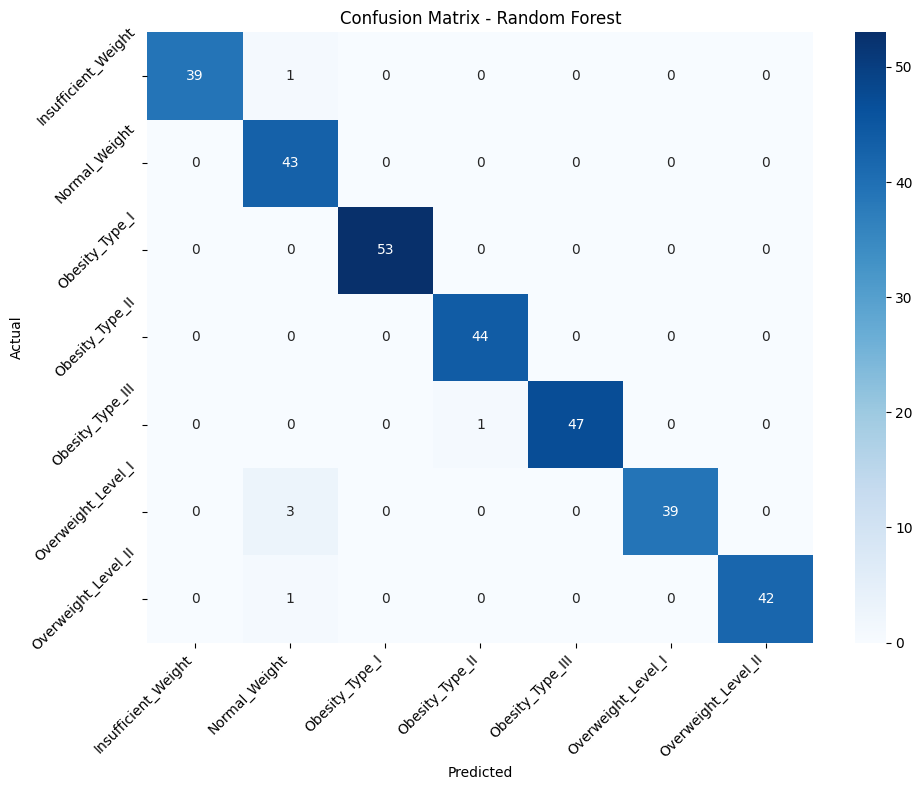

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

# Baseline models with pipelines
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
    ])
}

results = {}

for name, model in models.items():
    start_time = time.time()

    # Train
    model.fit(X_train, y_train)

    # Predict on validation
    y_pred = model.predict(X_val)

    # Evaluate
    acc = accuracy_score(y_val, y_pred)
    training_time = time.time() - start_time

    results[name] = {
        'accuracy': acc,
        'training_time': training_time
    }

    print(f"\n=== {name} ===")
    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")
    print(classification_report(y_val, y_pred, target_names=le.classes_, digits=3))

    # Save confusion matrix plot
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.lower().replace(" ", "_")}.png')  # ← SAVE THESE
    plt.show()


=== XGBoost ===
Validation Accuracy: 0.9649
Training Time: 0.48 seconds
                     precision    recall  f1-score   support

Insufficient_Weight      1.000     0.950     0.974        40
      Normal_Weight      0.878     1.000     0.935        43
     Obesity_Type_I      1.000     1.000     1.000        53
    Obesity_Type_II      0.957     1.000     0.978        44
   Obesity_Type_III      1.000     0.958     0.979        48
 Overweight_Level_I      0.973     0.857     0.911        42
Overweight_Level_II      0.955     0.977     0.966        43

           accuracy                          0.965       313
          macro avg      0.966     0.963     0.963       313
       weighted avg      0.967     0.965     0.965       313



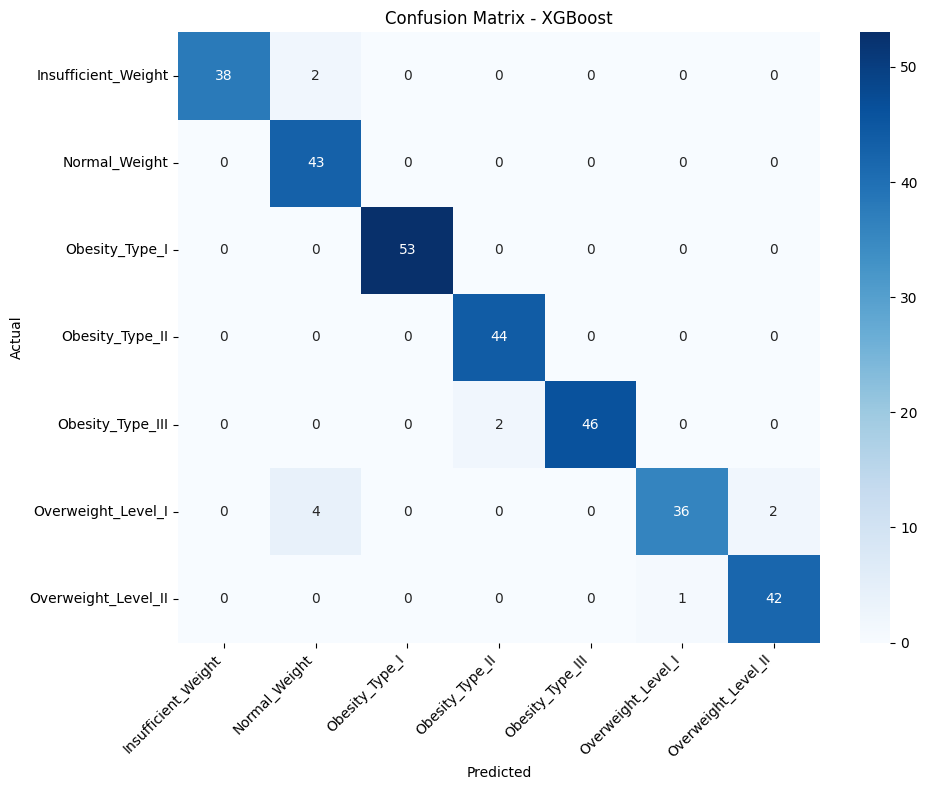


=== LightGBM ===
Validation Accuracy: 0.9649
Training Time: 0.72 seconds
                     precision    recall  f1-score   support

Insufficient_Weight      1.000     0.950     0.974        40
      Normal_Weight      0.878     1.000     0.935        43
     Obesity_Type_I      1.000     1.000     1.000        53
    Obesity_Type_II      0.957     1.000     0.978        44
   Obesity_Type_III      1.000     0.958     0.979        48
 Overweight_Level_I      0.973     0.857     0.911        42
Overweight_Level_II      0.955     0.977     0.966        43

           accuracy                          0.965       313
          macro avg      0.966     0.963     0.963       313
       weighted avg      0.967     0.965     0.965       313



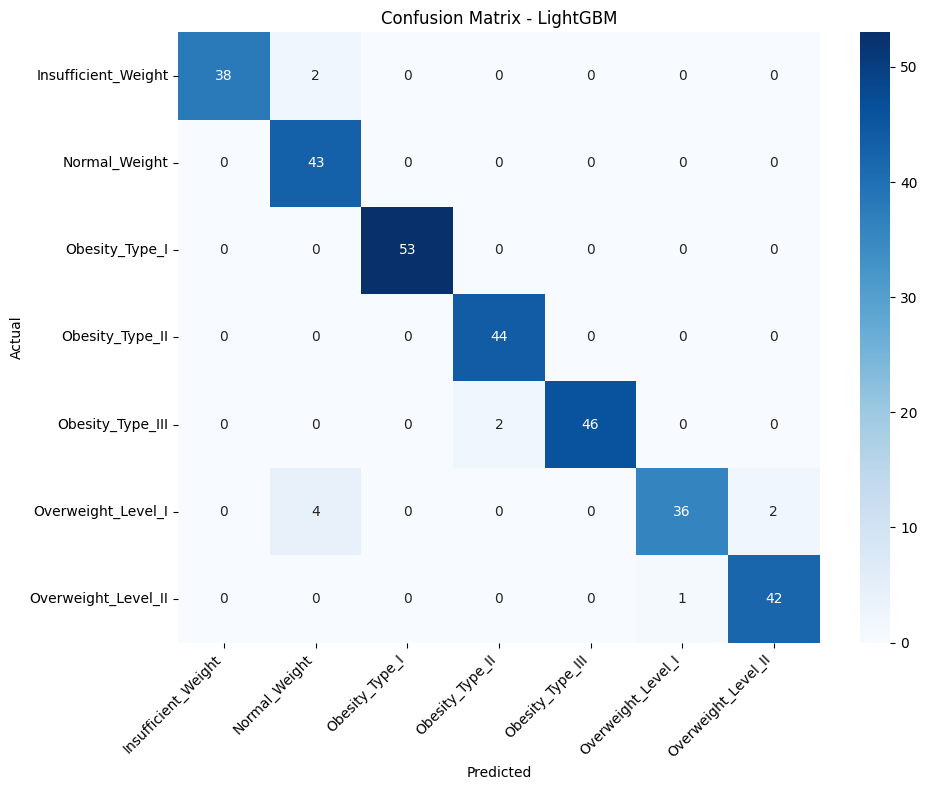

In [12]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Advanced models
advanced_models = {
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss'))
    ]),
    'LightGBM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LGBMClassifier(n_estimators=200, random_state=42, verbose=-1))
    ])
}

for name, model in advanced_models.items():
    start_time = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    training_time = time.time() - start_time

    results[name] = {
        'accuracy': acc,
        'training_time': training_time
    }

    print(f"\n=== {name} ===")
    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")
    print(classification_report(y_val, y_pred, target_names=le.classes_, digits=3))

    # Confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.lower()}.png')   # ← SAVE THESE
    plt.show()

In [13]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Tuned Random Forest
rf_param_grid = {
    'clf__n_estimators': [200, 300, 400],
    'clf__max_depth': [None, 15, 20, 25],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_grid, n_iter=15, cv=5,
    scoring='f1_macro', n_jobs=-1, random_state=42, verbose=1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest Params:", rf_search.best_params_)
print("Best CV Macro F1:", rf_search.best_score_)

# Tuned XGBoost
xgb_param_grid = {
    'clf__n_estimators': [200, 300],
    'clf__max_depth': [6, 8, 10],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.8, 0.9]
}

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_param_grid, n_iter=12, cv=5,
    scoring='f1_macro', n_jobs=-1, random_state=42, verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_search.best_params_)
print("Best CV Macro F1:", xgb_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Random Forest Params: {'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_depth': None}
Best CV Macro F1: 0.9821693569109209
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best XGBoost Params: {'clf__subsample': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 6, 'clf__learning_rate': 0.2}
Best CV Macro F1: 0.9809360720903386


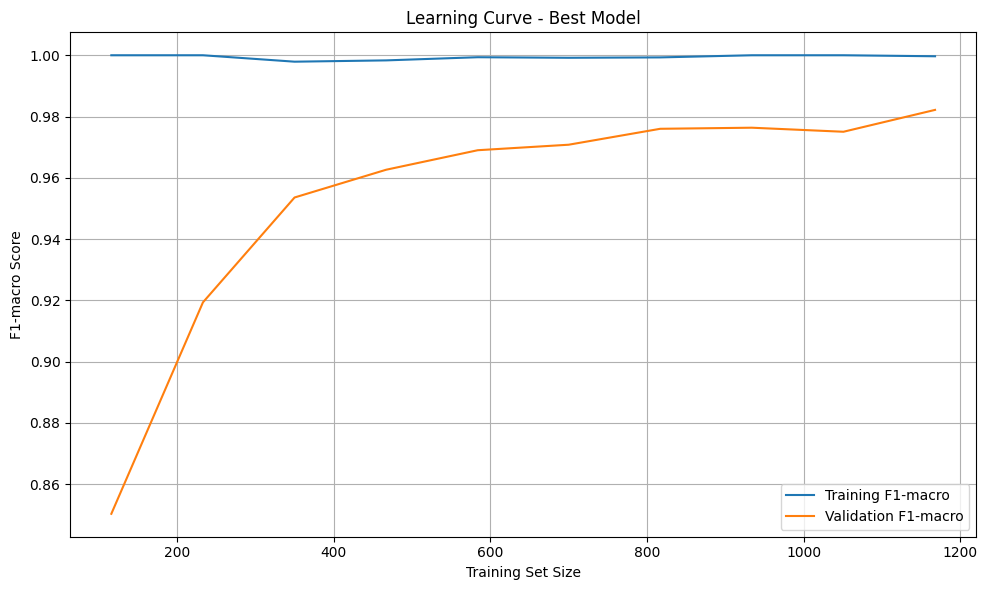

Learning curve saved. Gap between train and val indicates mild overfitting if any.


In [14]:
from sklearn.model_selection import learning_curve

# Use the best model from tuning
best_model = rf_search.best_estimator_

# Learning curve to check overfitting
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, random_state=42
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1-macro')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1-macro')
plt.title('Learning Curve - Best Model')
plt.xlabel('Training Set Size')
plt.ylabel('F1-macro Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve.png')   # ← SAVE THIS (very important for debugging section)
plt.show()

print("Learning curve saved. Gap between train and val indicates mild overfitting if any.")

=== Final Test Set Performance ===
                     precision    recall  f1-score   support

Insufficient_Weight     1.0000    0.9750    0.9873        40
      Normal_Weight     0.9130    1.0000    0.9545        42
     Obesity_Type_I     0.9815    1.0000    0.9907        53
    Obesity_Type_II     1.0000    0.9778    0.9888        45
   Obesity_Type_III     1.0000    1.0000    1.0000        49
 Overweight_Level_I     1.0000    0.9512    0.9750        41
Overweight_Level_II     1.0000    0.9773    0.9885        44

           accuracy                         0.9841       314
          macro avg     0.9849    0.9830    0.9835       314
       weighted avg     0.9852    0.9841    0.9842       314



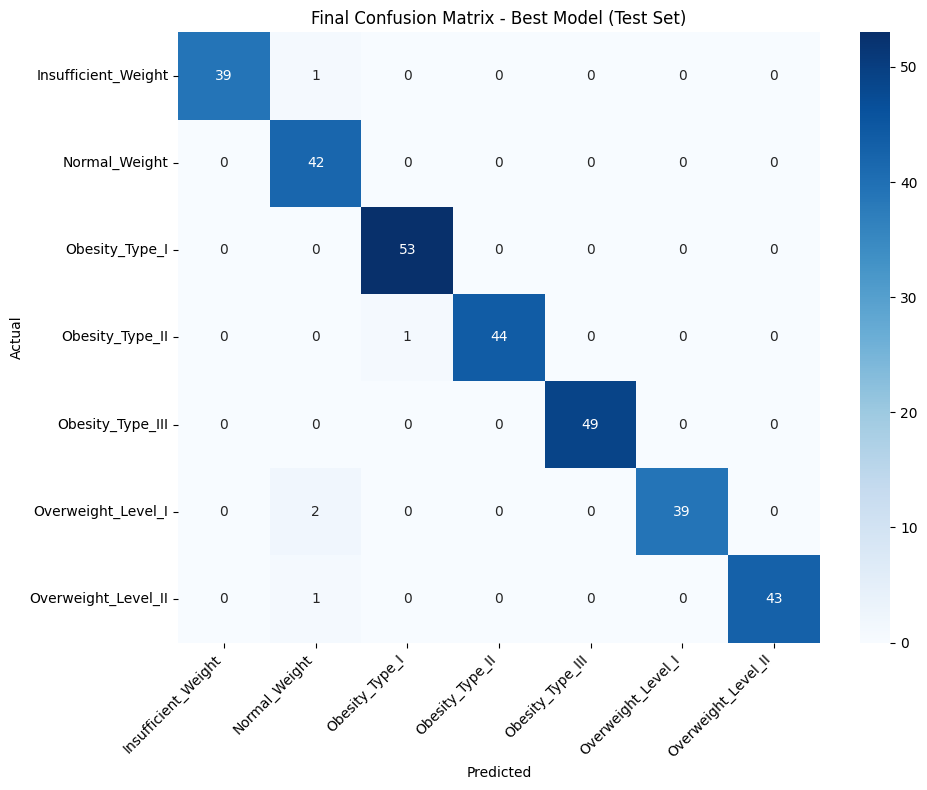

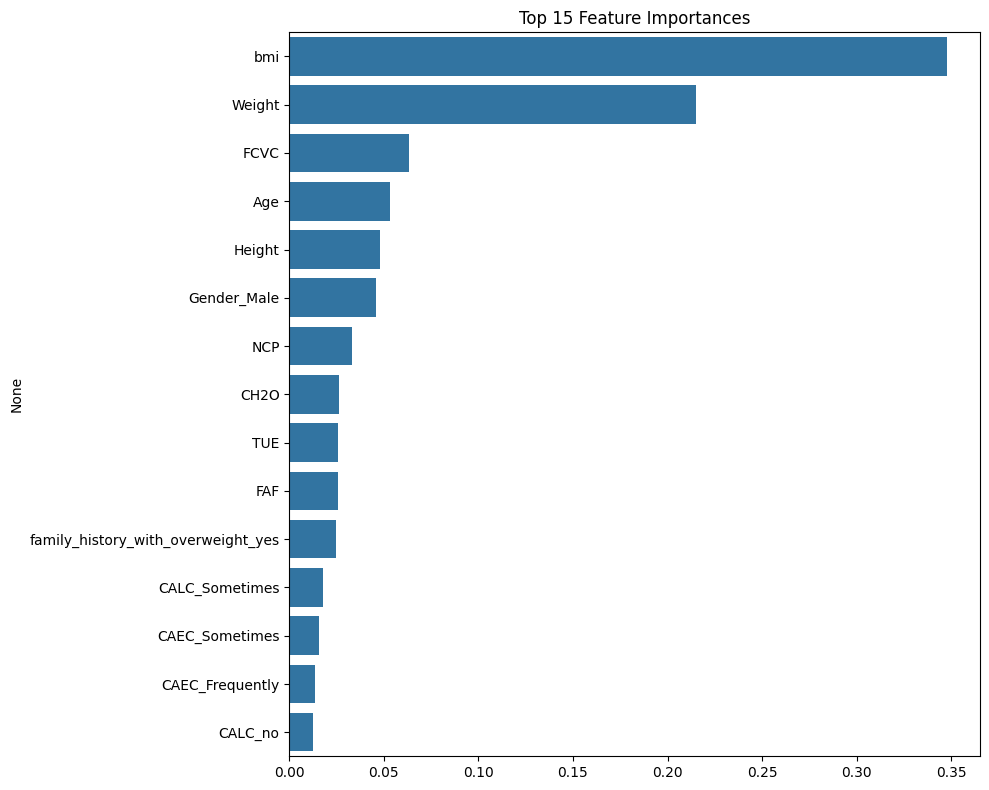


Top 10 Important Features:
bmi            0.347895
Weight         0.214880
FCVC           0.063411
Age            0.053222
Height         0.048154
Gender_Male    0.045955
NCP            0.033374
CH2O           0.026089
TUE            0.025591
FAF            0.025586
dtype: float64


In [15]:
# Final evaluation on hold-out test set
y_test_pred = best_model.predict(X_test)

print("=== Final Test Set Performance ===")
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4))

# Confusion matrix on test set
plt.figure(figsize=(10, 8))
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final Confusion Matrix - Best Model (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('final_confusion_matrix_test.png')   # ← SAVE THIS
plt.show()

# Feature importance (for Random Forest)
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    importances = best_model.named_steps['clf'].feature_importances_
    feature_names = X_train.columns
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=feat_imp.values, y=feat_imp.index)
    plt.title('Top 15 Feature Importances')
    plt.tight_layout()
    plt.savefig('feature_importance.png')   # ← SAVE THIS
    plt.show()

    print("\nTop 10 Important Features:")
    print(feat_imp.head(10))

In [19]:
import joblib

# Save the best model and label encoder
joblib.dump(best_model, 'best_obesity_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Best model and label encoder saved successfully!")

Best model and label encoder saved successfully!
